<div style="background: white;
            padding: 30px 35px;
            border-radius: 8px;
            border-left: 6px solid #e94560;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;">

<h1 style="margin-bottom: 5px;">NB01: Data Collection — Portfolio Risk Dashboard</h1>

<p style="font-weight: bold; margin-top: 0;">Personal Project · Portfolio Risk & Data Science · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 11th April 2026</li>
    <li>🎯 <strong>Purpose:</strong> Collect real historical price data for a 5-asset portfolio and prepare it for downstream risk modelling</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li>Yahoo Finance via <code>yfinance</code> API</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/prices.csv</code> — cleaned daily adjusted closing prices</li>
    <li><code>../data/returns.csv</code> — daily log returns</li>
    <li><code>../data/price_history.png</code> — normalised price chart</li>
    <li><code>../data/return_distributions.png</code> — return distribution plots</li>
    <li><code>../data/correlation_matrix.png</code> — correlation heatmap</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Adjusted price download with <code>yfinance</code></li>
    <li>Log return computation</li>
    <li>Missing value handling with forward fill</li>
    <li>Normalised price visualisation with crisis shading</li>
    <li>Correlation analysis</li>
</ul>

<p><strong>Workflow:</strong> Download → Clean → Visualise Prices → Compute Returns → Correlation → Save</p>

</div>

## ⚙️ Importing Libraries

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📋 Section 1: Configuration & Portfolio Setup

### 📍 Define Portfolio

In [3]:
TICKERS = {
    "SPY":  "S&P 500 ETF",
    "TLT":  "20Y US Treasury ETF",
    "GLD":  "Gold ETF",
    "QQQ":  "Nasdaq 100 ETF",
    "EEM":  "Emerging Markets ETF"
}

START_DATE = "2016-01-01"
END_DATE   = "2025-12-31"
WEIGHTS    = [0.35, 0.25, 0.15, 0.15, 0.10]

print(f"✅ Portfolio configured")
print(f"📅 Period  : {START_DATE} → {END_DATE}")
print(f"📊 Assets  : {list(TICKERS.keys())}")
print(f"⚖️  Weights : {WEIGHTS} (sum = {sum(WEIGHTS)})")

✅ Portfolio configured
📅 Period  : 2016-01-01 → 2025-12-31
📊 Assets  : ['SPY', 'TLT', 'GLD', 'QQQ', 'EEM']
⚖️  Weights : [0.35, 0.25, 0.15, 0.15, 0.1] (sum = 1.0)


## 📥 Section 2: Download Price Data

### 📍 Pull Adjusted Closing Prices from Yahoo Finance

In [4]:
print("⏳ Downloading data...")

raw    = yf.download(list(TICKERS.keys()), start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=False)
prices = raw["Close"].copy()
prices.columns.name = None
prices.index.name   = "Date"

print(f"✅ Download complete — Shape: {prices.shape}")
print(f"📅 Range: {prices.index[0].date()} → {prices.index[-1].date()}")
prices.head()

⏳ Downloading data...
✅ Download complete — Shape: (2513, 5)
📅 Range: 2016-01-04 → 2025-12-30


,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2016-01-04,25.081514,102.889999,101.717293,169.908142,91.679726
2016-01-05,25.137587,103.180000,101.540810,170.195572,91.309860
2016-01-06,24.656946,104.669998,100.565430,168.048645,92.540321
2016-01-07,23.895933,106.150002,97.416389,164.016937,92.706413
2016-01-08,23.639587,105.680000,96.617508,162.216553,93.121552


## 🧹 Section 3: Data Cleaning

### 📍 Check & Handle Missing Values

In [5]:
print("🔍 Missing values per asset:")
print(prices.isnull().sum())

prices = prices.ffill().dropna()

print(f"\n✅ After cleaning — Shape: {prices.shape}")
print(f"❌ Remaining nulls: {prices.isnull().sum().sum()}")

🔍 Missing values per asset:
EEM    0
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64

✅ After cleaning — Shape: (2513, 5)
❌ Remaining nulls: 0


## 📈 Section 4: Price Visualisation

### 📍 Plot Normalised Price History

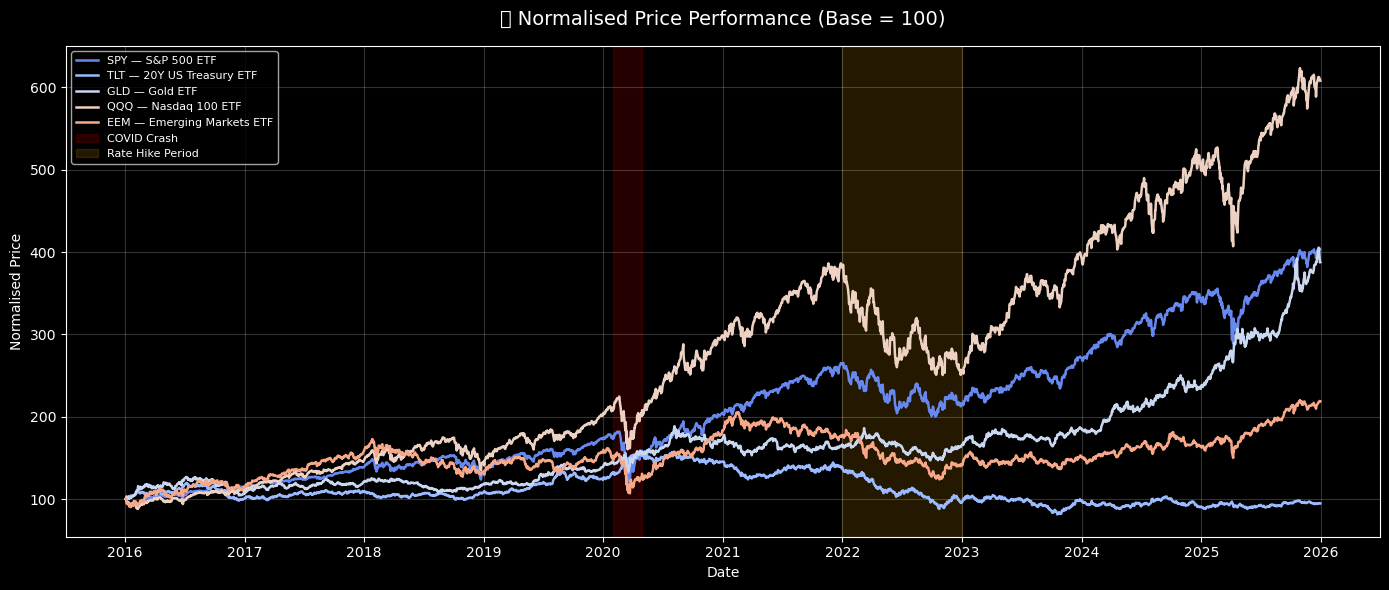

💾 Saved to ../figures/price_history.png


In [12]:
normalised = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))

for ticker, label in TICKERS.items():
    ax.plot(normalised.index, normalised[ticker],
            label=f"{ticker} — {label}", linewidth=1.8)

ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"),
           alpha=0.15, color="red", label="COVID Crash")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
           alpha=0.15, color="orange", label="Rate Hike Period")

ax.set_title("📈 Normalised Price Performance (Base = 100)", fontsize=14, pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Price")
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/price_history.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/price_history.png")

## 📉 Section 5: Log Returns

### 📍 Step 1: Compute Daily Log Returns

In [7]:
returns = np.log(prices / prices.shift(1)).dropna()

print(f"✅ Log returns computed — Shape: {returns.shape}")
returns.describe().round(4)

✅ Log returns computed — Shape: (2512, 5)


,EEM,GLD,QQQ,SPY,TLT
count,2512.0000,2512.0000,2512.0000,2512.0000,2512.0000
mean,0.0003,0.0005,0.0007,0.0006,-0.0000
std,0.0129,0.0093,0.0141,0.0114,0.0094
min,-0.1333,-0.0664,-0.1276,-0.1159,-0.0690
25%,-0.0062,-0.0045,-0.0050,-0.0036,-0.0057
50%,0.0009,0.0007,0.0013,0.0007,0.0003
75%,0.0075,0.0055,0.0078,0.0059,0.0054
max,0.0775,0.0479,0.1134,0.0999,0.0725


### 📍 Step 2: Plot Return Distributions

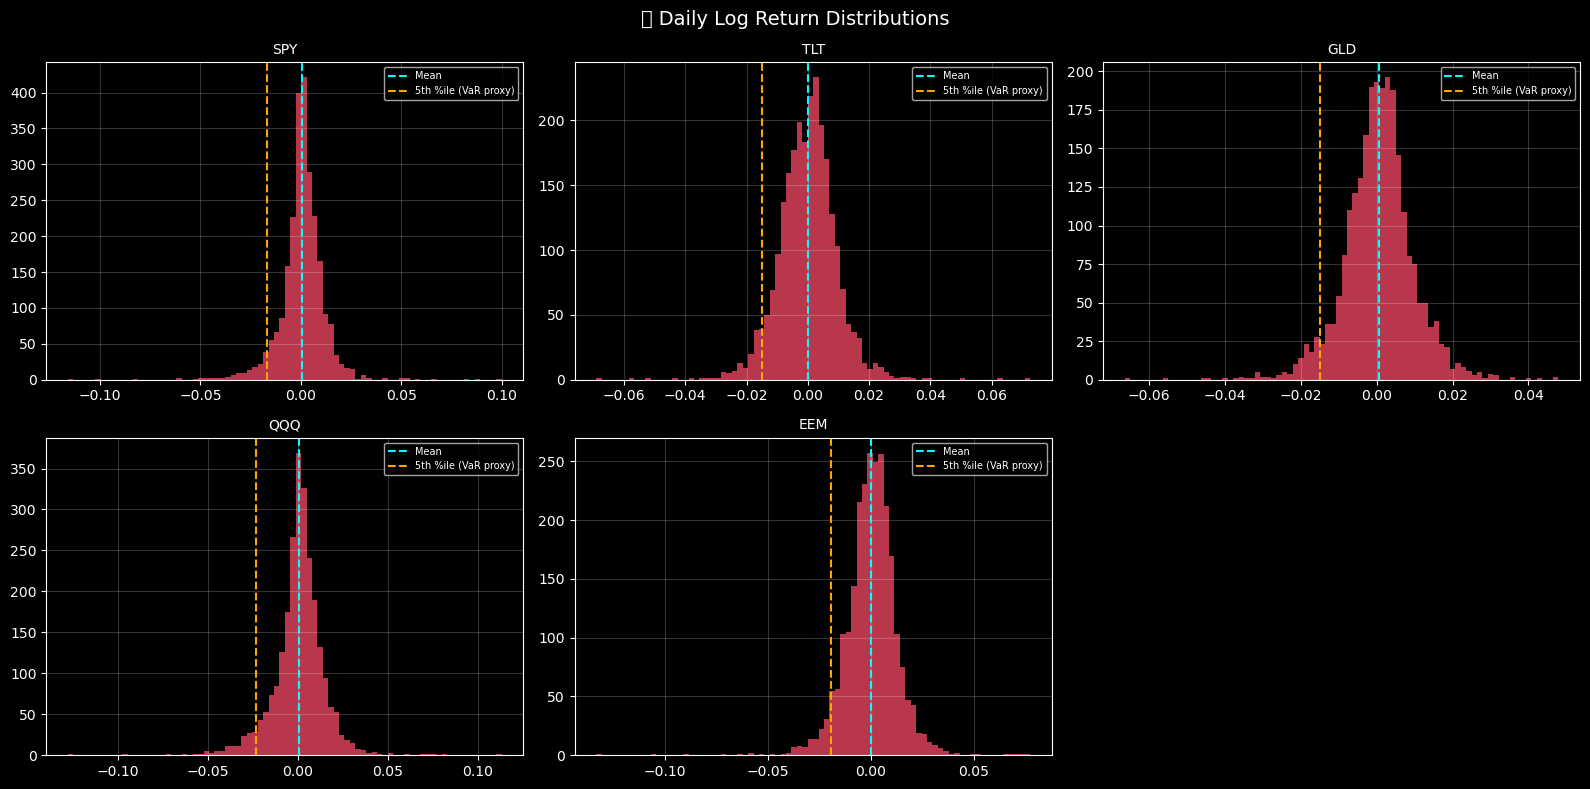

💾 Saved to ../figures/return_distributions.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS.keys()):
    axes[i].hist(returns[ticker], bins=80, color="#e94560", edgecolor="none", alpha=0.8)
    axes[i].axvline(returns[ticker].mean(), color="cyan", linestyle="--", label="Mean")
    axes[i].axvline(returns[ticker].quantile(0.05), color="orange",
                    linestyle="--", label="5th %ile (VaR proxy)")
    axes[i].set_title(f"{ticker}", fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.2)

axes[-1].set_visible(False)
fig.suptitle("📉 Daily Log Return Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/return_distributions.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/return_distributions.png")

## 🔗 Section 6: Correlation Analysis

### 📍 Correlation Heatmap

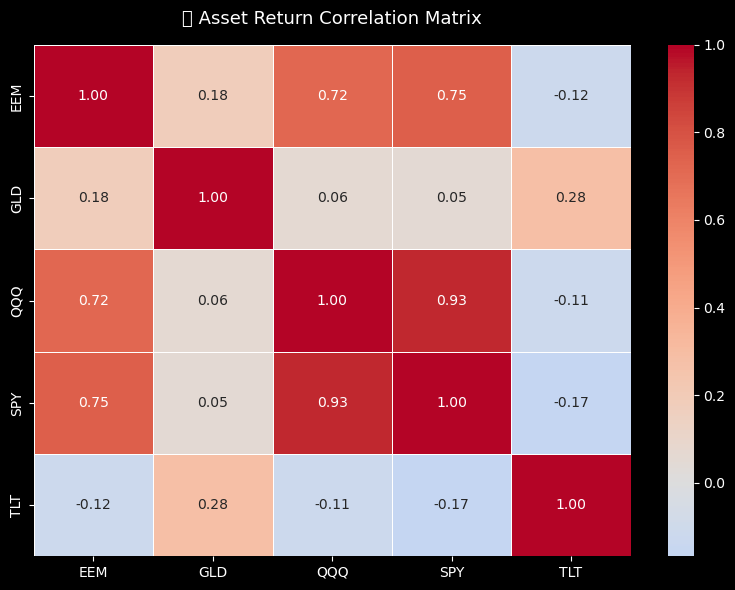


💡 Assets with low/negative correlation reduce portfolio risk through diversification.


In [14]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("🔗 Asset Return Correlation Matrix", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../figures/correlation_matrix.png", dpi=150)
plt.show()

print("\n💡 Assets with low/negative correlation reduce portfolio risk through diversification.")

## 💾 Section 7: Save Data

### 📍 Export to CSV

In [15]:
prices.to_csv("../data/raw/prices.csv")
returns.to_csv("../data/processed/returns.csv")

print("✅ Files saved:")
print("   📄 ../data/raw/prices.csv")
print("   📄 ../data/processed/returns.csv")
print("\n🚀 Ready for NB02 — Risk Modelling (VaR & Expected Shortfall)")

✅ Files saved:
   📄 ../data/raw/prices.csv
   📄 ../data/processed/returns.csv

🚀 Ready for NB02 — Risk Modelling (VaR & Expected Shortfall)
